# Load datasets from Siglent Spectrum Analyzer

## Set-up
In order to load the datasets saved in formats specific to siglent SA (`trc`), we will need to install [highz-exp](https://github.com/alhosani-abdulla/Highz-EXP.git) pacakge. You can do that by running the following command in your terminal:
```bash
git clone https://github.com/alhosani-abdulla/Highz-EXP.git
cd Highz-EXP
pipenv install
```
This is done only once. After that, you can run the following command to activate the virtual environment:
```bash
pipenv shell
```

In [1]:
# import the main module
from highz_exp.load_trc import TraceLoader
from os.path import join as pjoin
import os

In [2]:
# inspect what's contained
trcloader = TraceLoader(pjoin(os.getcwd(), '../data/resistor_cable.trc'))
trcloader.list_traces()

['TRACE1', 'TRACE2', 'TRACE3', 'TRACE4']

In [3]:
# inspect trace 1 data
f, s = trcloader.load_trace(trace=1) # returns frequency and signal arrays
print(f.shape, s.shape)

(751,) (751,)


## Intro to Class `Spectrum`
To better visualize the trace data, we can export them to a `Spectrum` object from `highz_exp`. This class is designed to hold the frequency and signal data, and provides useful methods for plotting and analysis. 

In [22]:
# load the first trace into a Spectrum object
spectrum_1 = trcloader.load_trc_to_spec(trace=1, name='Cable-Resistor1')

# Uncomment to visualize the first spectrum
# fig, ax = spectrum_1.plot()

In [23]:
# load the remaining traces into Spectrum objects
spectrum_2 = trcloader.load_trc_to_spec(trace=2, name='Cable-Resistor2')
spectrum_3 = trcloader.load_trc_to_spec(trace=3, name='Cable-Resistor3')
spectrum_4 = trcloader.load_trc_to_spec(trace=4, name='Cable-Resistor4')

We can use another functionality from `highz_exp` to plot all traces together. 

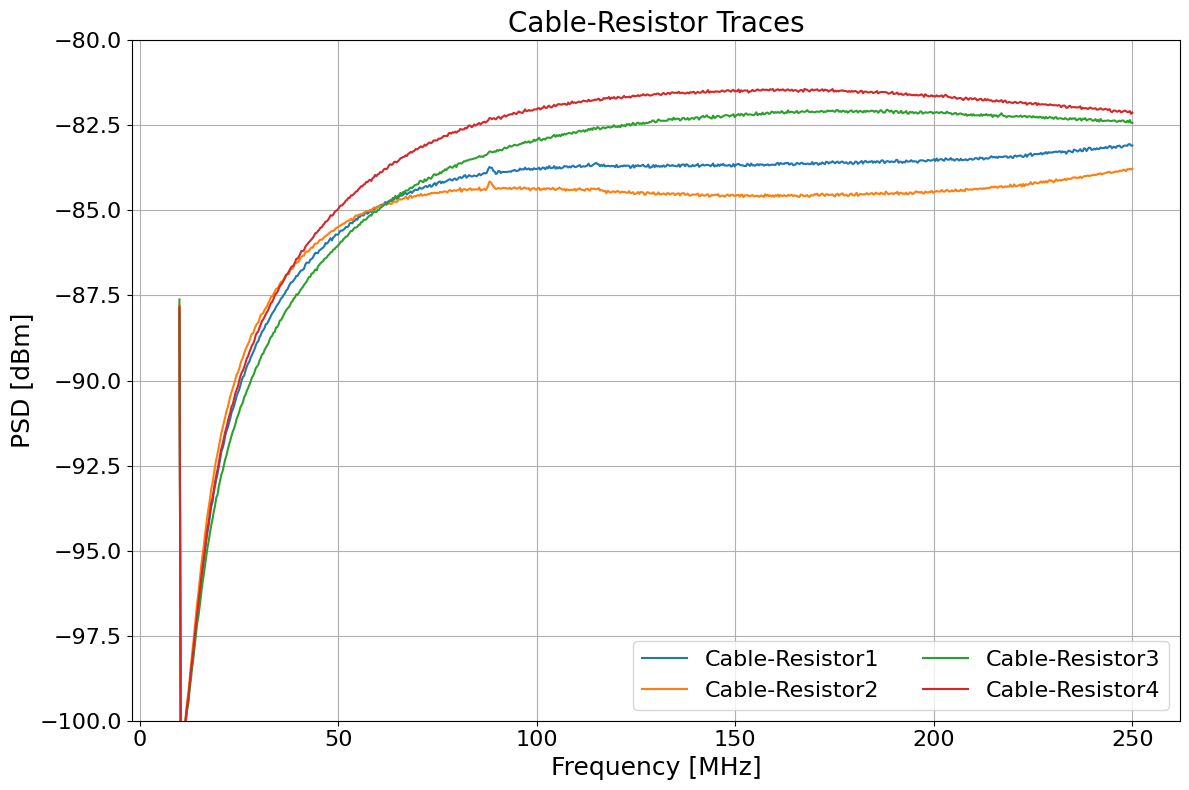

In [25]:
from highz_exp import plotter
plotter.plot_spectra([spectrum_1, spectrum_2, spectrum_3, spectrum_4], title='Cable-Resistor Traces',
        y_range=(-100, -80))